In [1]:
import numpy as np
import scipy

mu = 1.3271244e11  # gravitational parameter (km^3/s^2)


#KEPLER EQUATION SOLVER
def mean_motion(a, mu):
    return np.sqrt(mu) / a**1.5 

def mean_anomaly(M0, n, t, t0):
    return M0 + n * (t - t0) * 86400

def keplers_equation(E, e, M):
    return E - e * np.sin(E) - M

def true_anomaly(M, e):
    
    if M > np.pi:
        E0 = M - e/2
    else:
        E0 = M + e/2

    E = scipy.optimize.newton(keplers_equation, E0, args=(e, M), tol=1e-12)

    return 2 * np.arctan(np.sqrt((1 + e) / (1 - e)) * np.tan(E / 2))



#TRASFORMATION FUNCTION
def sv_from_coe(a, e, RAAN, i, w, mu, TA):  

    i = np.radians(i)
    w = np.radians(w)
    RAAN = np.radians(RAAN)
       
    r_perifocal = a * (1 - e**2) / (1 + e * np.cos(TA)) * np.array([np.cos(TA), np.sin(TA), 0])
    v_perifocal = mu / np.sqrt(mu * a * (1 - e**2)) * np.array([-np.sin(TA), e + np.cos(TA), 0])
    
    R_z_RA = np.array([[np.cos(RAAN), -np.sin(RAAN), 0],
                       [np.sin(RAAN), np.cos(RAAN), 0],
                       [0, 0, 1]])
    
    R_x_incl = np.array([[1, 0, 0],
                         [0, np.cos(i), -np.sin(i)],
                         [0, np.sin(i), np.cos(i)]])
    
    R_z_w = np.array([[np.cos(w), -np.sin(w), 0],
                      [np.sin(w), np.cos(w), 0],
                      [0, 0, 1]])

    Q = np.dot(R_z_RA, np.dot(R_x_incl, R_z_w))

    r = np.dot(Q, r_perifocal)
    v = np.dot(Q, v_perifocal)

    return r, v



#EPHEMERIS
def sv_from_t(a, e, RAAN, i, w, mu, t, t0, M0):

    n = mean_motion(a, mu)
    M = mean_anomaly(np.deg2rad(M0), n, t, t0)
    TA = true_anomaly(M, e)
    return sv_from_coe(a, e, RAAN, i, w, mu, TA)




# units: a [km], e [-], i/Ω/ω/M [deg]
E_a = 1.495988209443421e8
E_e = 1.669829008180246e-2
E_i = 3.248050135173038e-3
E_RAAN = 1.744712892867145e2
E_w = 2.884490093009512e2
E_M0 = 2.621190445180298e1

E_n = mean_motion(E_a, mu)

Y_a = 3.764419202360106e8     
Y_e = 6.616071771587672e-1
Y_i = 3.408286057191753e0
Y_RAAN = 2.713674649188756e2
Y_w = 1.343644678984687e2
Y_M0 = 1.693237490356061e1

Y_n = mean_motion(Y_a, mu)




t0 = 2460705.5  # JD
t = t0 + 100


Y_TA_0 = true_anomaly(np.deg2rad(Y_M0), Y_e)
print(np.rad2deg(Y_TA_0))


Y_M = mean_anomaly(np.deg2rad(Y_M0), Y_n, t, t0)
Y_TA = true_anomaly(Y_M, Y_e)
print(np.rad2deg(Y_TA))


SV_0 = sv_from_coe(Y_a, Y_e, Y_RAAN, Y_i, Y_w, mu, Y_TA_0)
print(SV_0)

SV = sv_from_coe(Y_a, Y_e, Y_RAAN, Y_i, Y_w, mu, Y_TA)
print(SV)

SV_0 = sv_from_t(Y_a, Y_e, Y_RAAN, Y_i, Y_w, mu, t0, t0, Y_M0)
print(SV_0)

SV = sv_from_t(Y_a, Y_e, Y_RAAN, Y_i, Y_w, mu, t, t0, Y_M0)
print(SV)


81.62486694492567
122.44040992266818
(array([-1.16943652e+08,  1.53462780e+08, -6.74460874e+06]), array([-31.71020385,  -3.62853803,  -1.89315467]))
(array([-3.20579979e+08,  6.72659396e+07, -1.89914452e+07]), array([-16.96480753, -12.94378023,  -1.02846633]))
(array([-1.16943652e+08,  1.53462780e+08, -6.74460874e+06]), array([-31.71020385,  -3.62853803,  -1.89315467]))
(array([-3.20579979e+08,  6.72659396e+07, -1.89914452e+07]), array([-16.96480753, -12.94378023,  -1.02846633]))


In [116]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

mu = 1.3271244e11  # gravitational parameter (km^3/s^2)


#KEPLER EQUATION SOLVER
def mean_motion(a, mu):
    return np.sqrt(mu) / a**1.5 

def mean_anomaly(M0, n, t, t0):
    return M0 + n * (t - t0) * 86400

def keplers_equation(E, e, M):
    return E - e * np.sin(E) - M

def true_anomaly(M, e):
    
    if M > np.pi:
        E0 = M - e/2
    else:
        E0 = M + e/2

    E = scipy.optimize.newton(keplers_equation, E0, args=(e, M), tol=1e-12)

    return 2 * np.arctan(np.sqrt((1 + e) / (1 - e)) * np.tan(E / 2))



#TRASFORMATION FUNCTION
def sv_from_coe(a, e, RAAN, i, w, mu, TA):  

    i = np.radians(i)
    w = np.radians(w)
    RAAN = np.radians(RAAN)
       
    r_perifocal = a * (1 - e**2) / (1 + e * np.cos(TA)) * np.array([np.cos(TA), np.sin(TA), 0])
    v_perifocal = mu / np.sqrt(mu * a * (1 - e**2)) * np.array([-np.sin(TA), e + np.cos(TA), 0])
    
    R_z_RA = np.array([[np.cos(RAAN), -np.sin(RAAN), 0],
                       [np.sin(RAAN), np.cos(RAAN), 0],
                       [0, 0, 1]])
    
    R_x_incl = np.array([[1, 0, 0],
                         [0, np.cos(i), -np.sin(i)],
                         [0, np.sin(i), np.cos(i)]])
    
    R_z_w = np.array([[np.cos(w), -np.sin(w), 0],
                      [np.sin(w), np.cos(w), 0],
                      [0, 0, 1]])

    Q = np.dot(R_z_RA, np.dot(R_x_incl, R_z_w))

    r = np.dot(Q, r_perifocal)
    v = np.dot(Q, v_perifocal)

    return r, v



#EPHEMERIS
def sv_from_t(a, e, RAAN, i, w, mu, t, t0, M0):

    n = mean_motion(a, mu)
    M = mean_anomaly(np.deg2rad(M0), n, t, t0)
    TA = true_anomaly(M, e)
    return np.rad2deg(TA), sv_from_coe(a, e, RAAN, i, w, mu, TA)




# units: a [km], e [-], i/Ω/ω/M [deg]
E_a = 1.495988209443421e8
E_e = 1.669829008180246e-2
E_i = 3.248050135173038e-3
E_RAAN = 1.744712892867145e2
E_w = 2.884490093009512e2
E_M0 = 2.621190445180298e1


Y_a = 3.764419202360106e8     
Y_e = 6.616071771587672e-1
Y_i = 3.408286057191753e0
Y_RAAN = 2.713674649188756e2
Y_w = 1.343644678984687e2
Y_M0 = 1.693237490356061e1



t0 = 2460705.5  # JD
t = t0

R_E = []
R_Y = []

V_E = []
V_Y = []

dist = []
time = []


while t < (t0 + 365.25*10):

    SV_Y = sv_from_t(Y_a, Y_e, Y_RAAN, Y_i, Y_w, mu, t, t0, Y_M0)
    SV_E = sv_from_t(E_a, E_e, E_RAAN, E_i, E_w, mu, t, t0, E_M0)

    R_E.append(np.linalg.norm(SV_E[1][0]))
    V_E.append(np.linalg.norm(SV_E[1][1]))

    R_Y.append(np.linalg.norm(SV_Y[1][0]))
    V_Y.append(np.linalg.norm(SV_Y[1][1]))

    dist.append(np.linalg.norm(SV_E[1][0] - SV_Y[1][0]))

    time.append(t)

    t += 1


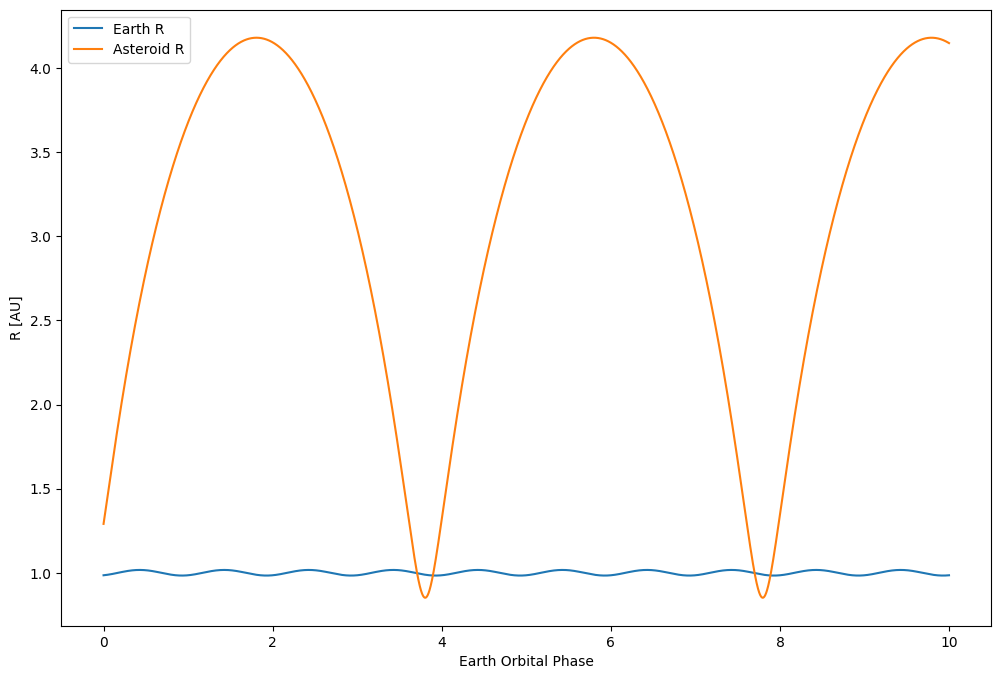

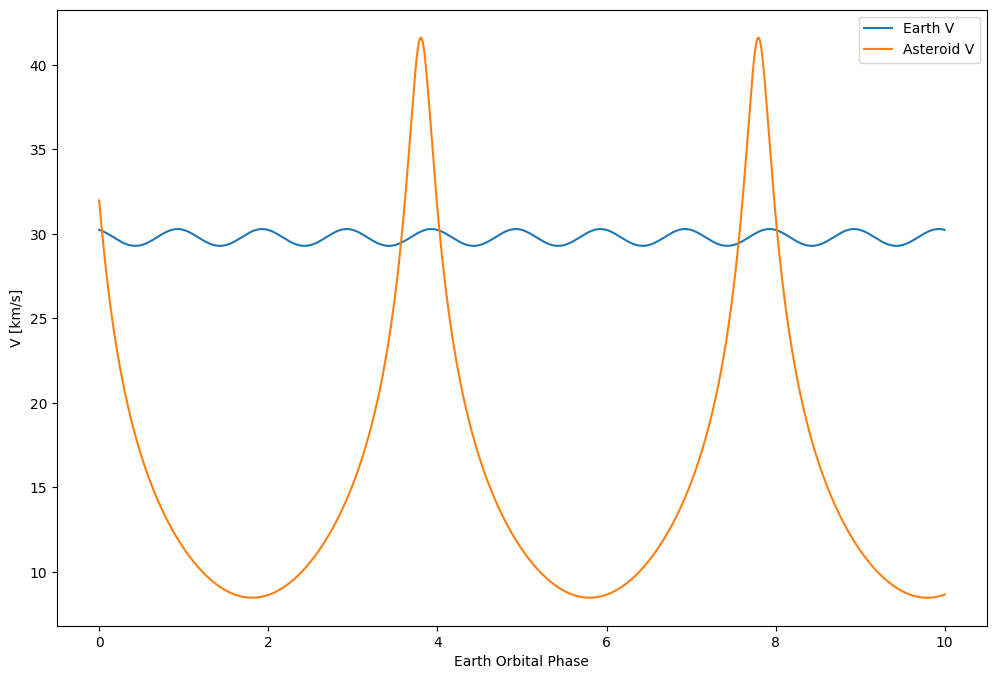

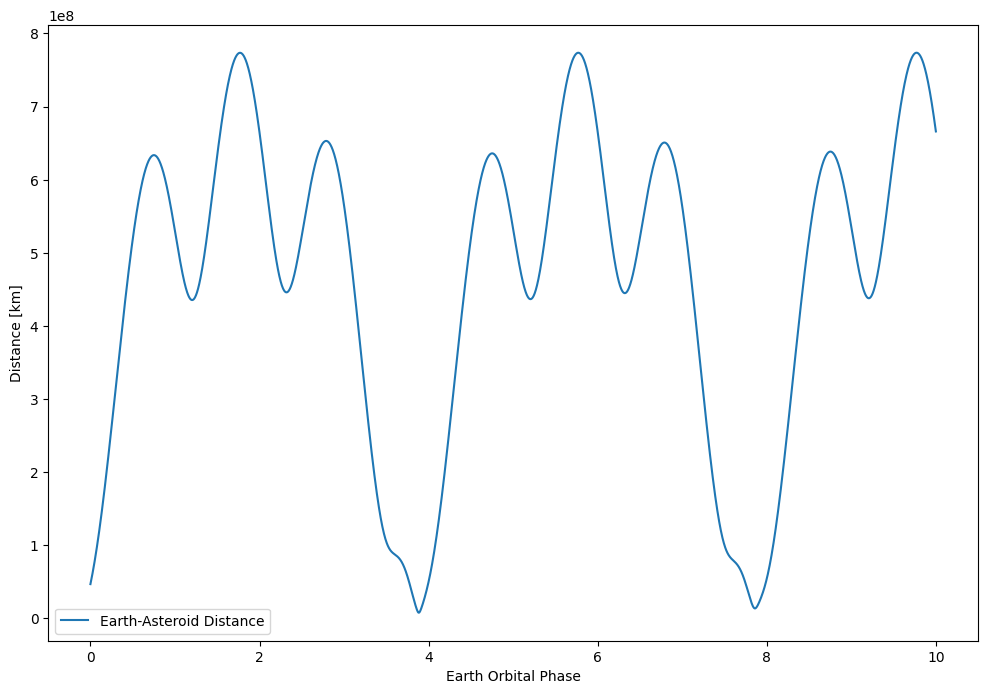

7627195.003520091


In [124]:
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.limits'] = (-3, 4)  # evita sci tranne casi estremi

plt.figure(figsize=(12,8))

plt.plot((np.array(time) - t0)/365.25, np.array(R_E)/149597871, label='Earth R')
plt.plot((np.array(time) - t0)/365.25, np.array(R_Y)/149597871, label='Asteroid R')
plt.xlabel('Earth Orbital Phase')
plt.ylabel('R [AU]')
plt.legend()
plt.show()

plt.figure(figsize=(12,8))

plt.plot((np.array(time) - t0)/365.25, np.array(V_E), label='Earth V')
plt.plot((np.array(time) - t0)/365.25, np.array(V_Y), label='Asteroid V')
plt.xlabel('Earth Orbital Phase')
plt.ylabel('V [km/s]')
plt.legend()
plt.show()

plt.figure(figsize=(12,8))

plt.plot((np.array(time) - t0)/365.25, np.array(dist), label='Earth-Asteroid Distance')
plt.xlabel('Earth Orbital Phase')
plt.ylabel('Distance [km]')
plt.legend()
plt.show()

print(np.min(np.array(dist)))